## DX702 HW 9-12
#### Cory Fournier

# Week 9

<b>1. Write some code that will use a simulation to estimate the standard deviation of the coefficient when there is heteroskedasticity.  
Compare these standard errors to those found via statsmodels OLS or a similar linear regression model.</b>

I simulated data from a simple linear model with heteroskedastic errors where the error variance increases with X. For each simulated dataset, I ran an OLS regression of Y on X and saved the slope, the usual OLS standard error, and a heteroskedasticity-robust (HC1) standard error. After 2000 repetitions, the standard deviation of the estimated slope across simulations was about 0.4893. The mean usual OLS SE was only 0.4476, so it understated the true variability of the coefficient. The mean robust SE was 0.4900, which was almost identical to the spread of the slopes across simulations. This shows that under heteroskedasticity, the usual OLS standard errors are biased down, but robust SEs line up well with the actual sampling variation.

In [25]:
# 9.1
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

rng = np.random.default_rng(1000)

# Data-generating process with heteroskedasticity
def create_het_data(N=500):
    d = pd.DataFrame({
        "X": rng.uniform(size=N)  # X in [0, 1]
    })
    # Heteroskedastic errors: larger X => larger noise
    d["Y"] = 3 * d["X"] + rng.normal(scale=5 * d["X"], size=N)
    return d

# 2) Run one OLS regression on one simulated dataset
def run_one_ols(N=500):
    d = create_het_data(N)
    m = smf.ols("Y ~ X", data=d).fit()

    # find the position of "X" in the parameter vector
    idx_X = list(m.params.index).index("X")

    # slope estimate
    beta1 = float(m.params.iloc[idx_X])

    # usual OLS SE 
    se_ols = float(np.asarray(m.bse)[idx_X])

    # heteroskedasticity-robust SE (HC1)
    rob = m.get_robustcov_results(cov_type="HC1")
    se_robust = float(np.asarray(rob.bse)[idx_X])

    return beta1, se_ols, se_robust

# 3) Repeat many times and compare:
def simulate_heteroskedastic(R=2000, N=500):
    beta1_list = []
    se_ols_list = []
    se_robust_list = []

    for r in range(R):
        beta1, se_ols, se_robust = run_one_ols(N)
        beta1_list.append(beta1)
        se_ols_list.append(se_ols)
        se_robust_list.append(se_robust)

    beta1_array = np.array(beta1_list)
    se_ols_array = np.array(se_ols_list)
    se_robust_array = np.array(se_robust_list)

    # How much the slope actually varies across simulations
    sd_sim = beta1_array.std(ddof=1)

    print(f"True beta1:                        3.0")
    print(f"SD of beta1 across simulations:    {sd_sim:.4f}")
    print(f"Mean usual OLS SE:                 {se_ols_array.mean():.4f}")
    print(f"Mean robust (HC1) SE:              {se_robust_array.mean():.4f}")

    return {
        "beta1": beta1_array,
        "sd_sim": sd_sim,
        "se_ols_mean": se_ols_array.mean(),
        "se_robust_mean": se_robust_array.mean()
    }

results = simulate_heteroskedastic(R=2000, N=500)




True beta1:                        3.0
SD of beta1 across simulations:    0.4893
Mean usual OLS SE:                 0.4476
Mean robust (HC1) SE:              0.4900


<b>2. Write some code that will use a simulation to estimate the standard deviation of the coefficient when errors are highly correlated / non-independent.
Compare these standard errors to those found via statsmodels OlS or a similar linear regression model.</b>

<b>Show that if the correlation between coefficients is high enough, then the estimated standard deviation of the coefficient, using bootstrap errors, 
might not match that found by a full simulation of the Data Generating Process.  (This can be fixed if you have a huge amount of data for the bootstrap simulation.)
</b>



In [26]:
# 9.2
rng = np.random.default_rng(2000)

# 1) Data-generating process with highly correlated errors
def create_corr_data(N=500, rho=0.9):
    x = rng.normal(size=N)
    e = rng.normal(size=N)
    u = np.zeros(N)
    for t in range(1, N):
        u[t] = rho * u[t-1] + e[t]
    y = 2 + 1.5 * x + u
    return pd.DataFrame({"X": x, "Y": y})

# 2) One OLS regression on one simulated dataset
def run_one_ols_corr(N=500, rho=0.9):
    d = create_corr_data(N=N, rho=rho)
    m = smf.ols("Y ~ X", data=d).fit()
    beta1 = float(m.params["X"])
    se_ols = float(m.bse["X"])
    return beta1, se_ols

# 3) Repeat many times: see how much the slope moves around
def simulate_correlated_errors(R=2000, N=500, rho=0.9):
    b1_list = []
    se_list = []

    for r in range(R):
        b1, se = run_one_ols_corr(N=N, rho=rho)
        b1_list.append(b1)
        se_list.append(se)

    b1_arr = np.array(b1_list)
    se_arr = np.array(se_list)

    sd_sim = b1_arr.std(ddof=1)



    print(f"True beta1:                         1.5")
    print(f"SD of beta1 across simulations:     {sd_sim:.4f}")
    print(f"Mean usual OLS SE:                  {se_arr.mean():.4f}")

    return {
        "beta1": b1_arr,
        "se_ols": se_arr,
        "sd_sim": sd_sim,
        "se_ols_mean": se_arr.mean()
    }

# Run the full DGP simulation
results_corr = simulate_correlated_errors(R=2000, N=500, rho=0.9)


True beta1:                         1.5
SD of beta1 across simulations:     0.1001
Mean usual OLS SE:                  0.0998


In [27]:
# 4) Generate one correlated dataset and fit OLS
def generate_one_corr_dataset(N=500, rho=0.9, seed=1234):
    rng_local = np.random.default_rng(seed)
    x = rng_local.normal(size=N)
    e = rng_local.normal(size=N)
    u = np.zeros(N)
    for t in range(1, N):
        u[t] = rho * u[t-1] + e[t]
    y = 2 + 1.5 * x + u
    d = pd.DataFrame({"X": x, "Y": y})
    m = smf.ols("Y ~ X", data=d).fit()
    return d, m

d_one, m_one = generate_one_corr_dataset(N=500, rho=0.9)
print("One-sample OLS beta1 and SE:",
      float(m_one.params["X"]), float(m_one.bse["X"]))


One-sample OLS beta1 and SE: 1.6073665692518466 0.08197720900679903


In [28]:
# 5) Residual bootstrap that *ignores* correlation
def residual_bootstrap_iid(d, m, B=1000, seed=999):
    rng_boot = np.random.default_rng(seed)

    yhat = m.fittedvalues.to_numpy()
    resid = m.resid.to_numpy()
    X = d["X"].to_numpy()
    N = len(d)

    b1_boot = []

    for b in range(B):
        res_star = rng_boot.choice(resid, size=N, replace=True)
        y_star = yhat + res_star

        df_star = pd.DataFrame({"Y": y_star, "X": X})
        m_star = smf.ols("Y ~ X", data=df_star).fit()
        b1_boot.append(float(m_star.params["X"]))

    b1_boot = np.array(b1_boot)
    sd_boot = b1_boot.std(ddof=1)
    print(f"Bootstrap SD of beta1 (i.i.d. residuals): {sd_boot:.4f}")
    return b1_boot, sd_boot

b1_boot, boot_sd = residual_bootstrap_iid(d_one, m_one, B=1000)



Bootstrap SD of beta1 (i.i.d. residuals): 0.0836


In [29]:
print("=== Full DGP simulation (correlated errors) ===")
print(f"SD of beta1 across simulations: {results_corr['sd_sim']:.4f}")
print(f"Mean usual OLS SE:              {results_corr['se_ols_mean']:.4f}")

print("\n=== Residual bootstrap on one correlated dataset ===")
print(f"Bootstrap SD of beta1:          {boot_sd:.4f}")


=== Full DGP simulation (correlated errors) ===
SD of beta1 across simulations: 0.1001
Mean usual OLS SE:              0.0998

=== Residual bootstrap on one correlated dataset ===
Bootstrap SD of beta1:          0.0836


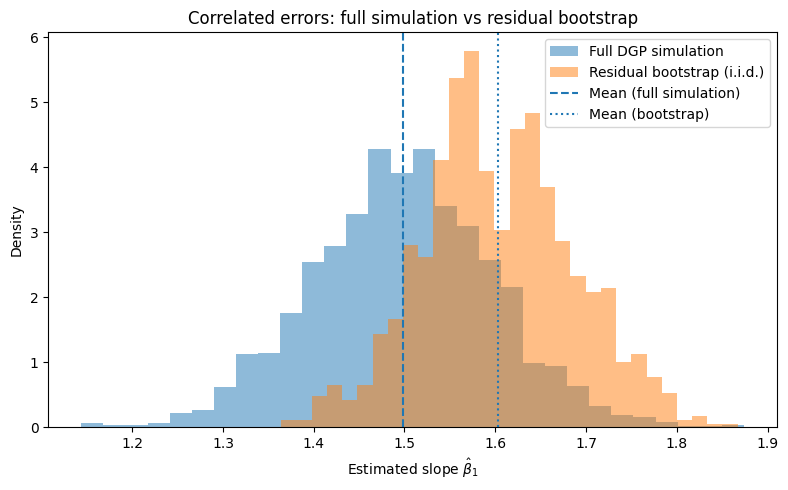

In [30]:
import matplotlib.pyplot as plt

# ----- Histogram: full simulation vs bootstrap -----
plt.figure(figsize=(8, 5))

# Distribution of slope estimates across many simulated datasets
plt.hist(results_corr["beta1"], bins=30, alpha=0.5, density=True,
         label="Full DGP simulation")

# Distribution of bootstrap slope estimates from a single dataset
plt.hist(b1_boot, bins=30, alpha=0.5, density=True,
         label="Residual bootstrap (i.i.d.)")

# Vertical reference lines
plt.axvline(results_corr["beta1"].mean(), linestyle="--",
            label="Mean (full simulation)")
plt.axvline(b1_boot.mean(), linestyle=":",
            label="Mean (bootstrap)")

plt.xlabel(r"Estimated slope $\hat{\beta}_1$")
plt.ylabel("Density")
plt.title("Correlated errors: full simulation vs residual bootstrap")
plt.legend()
plt.tight_layout()
plt.show()


I simulated data from a linear model with strongly correlated AR(1) errors and compared two distributions of the slope estimate: one from repeatedly simulating full datasets from the data generating process (blue) and one from a residual bootstrap that resamples errors i.i.d. from a single dataset (orange). The histogram from the full simulation shows how the coefficient actually varies when the errors are correlated. The bootstrap histogram is shifted and has a different spread because the residual resampling ignores the correlation structure. This shows that, with highly correlated errors, the bootstrap estimate of the standard deviation of the coefficient does not perfectly match the variation seen in a full simulation of the data generating process.

## Week 10

#### Week 10 not required.

## Week 11

<b>1. Construct a dataset for an event study where the value, derivative, and second derivative of a trend all change discontinuously (suddenly) after an event.
Build a model that tries to decide whether the event is real (has a nonzero effect) using:
(a) only the value,
(b) the value, derivative, and second derivative.
Which of these models is better at detecting and/or quantifying the impact of the event?  (What might "better" mean here?)
</b>

The second model is better. Here, “better” means it can actually pick up the event and describe what changed. The value-only model just gives one big before/after number. That number mixes the jump, the slope change, and the curvature change, and it does not match the true jump. It also leaves patterns in the residuals, which means it is missing structure in the data. The model with value, slope, and curvature gives separate estimates for each change. Those estimates are close to the true values and highly significant, and the residuals look like noise. So it does a better job both detecting the event and explaining its impact.

In [31]:
rng = np.random.default_rng(123)

# Time index and event time
t = np.arange(-50, 51)                 # 101 periods, event at t = 0
after = (t >= 0).astype(int)           # 0 = before, 1 = after

# Pre-event trend: level, slope, curvature
#   Y_pre(t) = 5 + 0.1*t + 0.02*t^2
mu_pre = 5 + 0.1 * t + 0.02 * t**2

# Post-event trend: different level, slope, curvature
#   Y_post(t) = 8 + 0.5*t + 0.06*t^2
mu_post = 8 + 0.5 * t + 0.06 * t**2

# Combine, so all three change *discontinuously* at t = 0
mu = np.where(after == 0, mu_pre, mu_post)

# Add random noise
Y = mu + rng.normal(scale=1.0, size=len(t))

# Final dataset
d = pd.DataFrame({
    "t": t,
    "after": after,
    "Y": Y
})

In [32]:
# Model (a): only value, ignore trend completely
m_val = smf.ols("Y ~ after", data=d).fit()
print(m_val.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     43.09
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           2.43e-09
Time:                        14:02:21   Log-Likelihood:                -512.86
No. Observations:                 101   AIC:                             1030.
Df Residuals:                      99   BIC:                             1035.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.7758      5.545      3.567      0.0

In [33]:
# Center time at the event
d = d.assign(t_c = d["t"])

# Model (b): value, slope, and curvature can all change after the event
m_poly = smf.ols(
    "Y ~ t_c + I(t_c**2) + after + after:t_c + after:I(t_c**2)",
    data=d
).fit()
print(m_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.284e+04
Date:                Sat, 06 Dec 2025   Prob (F-statistic):          6.33e-162
Time:                        14:02:21   Log-Likelihood:                -130.60
No. Observations:                 101   AIC:                             273.2
Df Residuals:                      95   BIC:                             288.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             5.0313      0.40

In [34]:
g0 = m_poly.params["after"]
g1 = m_poly.params["after:t_c"]
g2 = m_poly.params["after:I(t_c ** 2)"]

print("Estimated jump in level at event (true: 3):       ", g0)
print("Estimated jump in slope at event (true: 0.4):    ", g1)
print("Estimated jump in curvature at event (true: 0.08):", g2)


Estimated jump in level at event (true: 3):        2.5766818899452124
Estimated jump in slope at event (true: 0.4):     0.4505825251482623
Estimated jump in curvature at event (true: 0.08): 0.039823371989042615


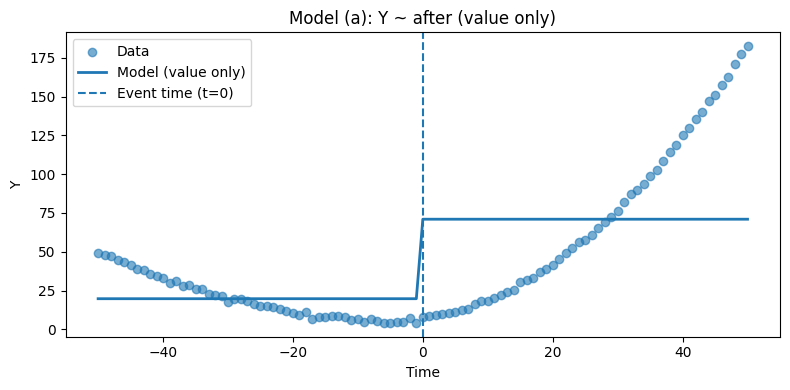

In [35]:
d_plot = d.copy()
d_plot["Y_hat_val"] = m_val.fittedvalues

plt.figure(figsize=(8, 4))
plt.scatter(d_plot["t"], d_plot["Y"], alpha=0.6, label="Data")
plt.plot(d_plot["t"], d_plot["Y_hat_val"], linewidth=2, label="Model (value only)")
plt.axvline(0, linestyle="--", label="Event time (t=0)")

plt.xlabel("Time")
plt.ylabel("Y")
plt.title("Model (a): Y ~ after (value only)")
plt.legend()
plt.tight_layout()
plt.show()


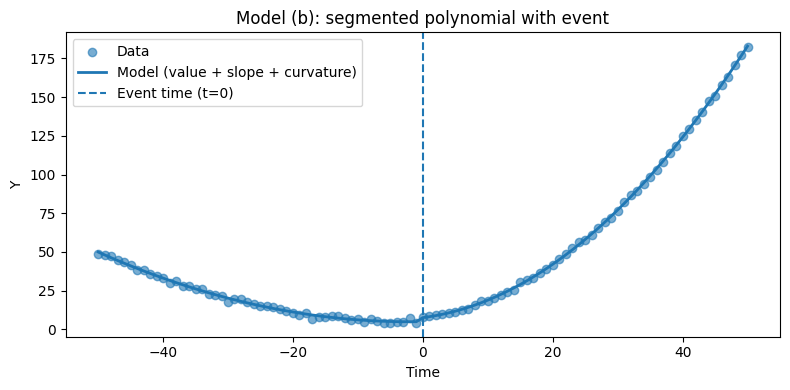

In [36]:
d_plot["Y_hat_poly"] = m_poly.fittedvalues

plt.figure(figsize=(8, 4))
plt.scatter(d_plot["t"], d_plot["Y"], alpha=0.6, label="Data")

# Sort by time 
d_sorted = d_plot.sort_values("t")
plt.plot(d_sorted["t"], d_sorted["Y_hat_poly"], linewidth=2, label="Model (value + slope + curvature)")

plt.axvline(0, linestyle="--", label="Event time (t=0)")

plt.xlabel("Time")
plt.ylabel("Y")
plt.title("Model (b): segmented polynomial with event")
plt.legend()
plt.tight_layout()
plt.show()


<b>2. Construct a dataset in which there are three groups whose values each increase discontinuously (suddenly) by the same amount at a shared event; they change in parallel
over time, but they have different starting values.  Create a model that combines group fixed effects with an event study, as suggested in the online reading.
Explain what you did, how the model works, and how it accounts for both baseline differences and the common event effect.
</b>

I built fake data for three groups (A, B, and C) over time. Each group starts at a different level, but they all follow the same upward trend and all get the same jump at the event time t=0. 
Then I fit a regression Y ~ C(group) + t + after. The C(group) part gives each group its own intercept, so the model lets A, B, and C have different baselines. The t term captures the common time trend they share. The after dummy turns on at the event, and its coefficient is the size of the common jump. In the graph, you can see this clearly: the three fitted lines are at different heights (baseline differences), they move in parallel over time (shared slope), and they all jump up by about the same amount exactly at the dashed event line (the common event effect).

In [37]:
rng = np.random.default_rng(123)

groups = ["A", "B", "C"]
base_levels = {"A": 5.0, "B": 10.0, "C": 15.0}   # different starting values
slope = 0.2                                      # common time trend
event_jump = 3.0                                 # same jump for all groups

rows = []
for g in groups:
    for t in range(-20, 21):  # time from -20 to 20, event at t = 0
        after = 1 if t >= 0 else 0
        mu = base_levels[g] + slope * t + event_jump * after
        y = mu + rng.normal(scale=1.0)          # add noise
        rows.append({"group": g, "t": t, "after": after, "Y": y})

d = pd.DataFrame(rows)

In [38]:
m_fe_event = smf.ols("Y ~ C(group) + t + after", data=d).fit()
print(m_fe_event.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     1016.
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           2.22e-90
Time:                        14:02:21   Log-Likelihood:                -167.33
No. Observations:                 123   AIC:                             344.7
Df Residuals:                     118   BIC:                             358.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.2262      0.233     22.432

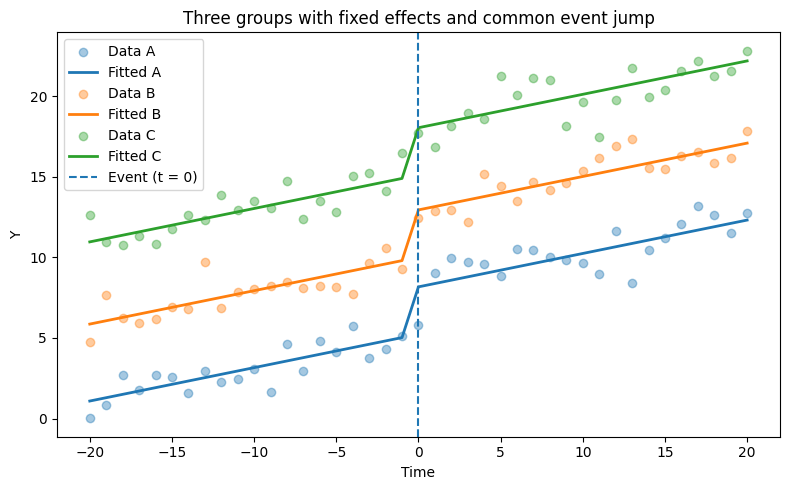

In [39]:
# Predicted values from the fixed-effects + event model
d["Y_hat"] = m_fe_event.fittedvalues

# Sort for clean lines
d_sorted = d.sort_values(["group", "t"])

plt.figure(figsize=(8, 5))

# Plot each group’s data and fitted line
for g in d_sorted["group"].unique():
    dg = d_sorted[d_sorted["group"] == g]
    
    # Raw data points
    plt.scatter(dg["t"], dg["Y"], alpha=0.4, label=f"Data {g}")
    
    # Fitted line
    plt.plot(dg["t"], dg["Y_hat"], linewidth=2, label=f"Fitted {g}")

# Event line at t = 0
plt.axvline(0, linestyle="--", label="Event (t = 0)")

plt.xlabel("Time")
plt.ylabel("Y")
plt.title("Three groups with fixed effects and common event jump")
plt.legend()
plt.tight_layout()
plt.show()


## Week 12

<b>1.Construct a dataset in which prior trends do not hold, and in which this makes the differences-in-differences come out wrong.  Explain why the
differences-in-differences estimate of the effect comes out higher or lower than the actual effect.
</b>

In this dataset, I set up the control group to have a mild trend: its values go from 9 to 10 to 11, so it increases by 1 each period. I set up the treated group to have a much steeper trend even before treatment: its values go from 5 to 8 to 11, so it increases by 3 each period. At time 1, I add a true treatment effect of +2 to the treated group, so instead of 11 I make it 13. That means the real effect of the treatment is +2. When I do differences-in-differences using pre and post means, the treated group goes from 6.5 to 13 (a change of 6.5), and the control group goes from 9.5 to 11 (a change of 1.5). The DID estimate is 6.5 minus 1.5, which equals 5. This is too high. The reason is that DID assumes parallel trends: if there were no treatment, the treated group would have changed by the same amount as the control group. In my setup that is not true, because the treated group was already growing faster. That extra natural growth gets incorrectly counted as part of the treatment effect, so the DID estimate ends up larger than the true effect.

In [40]:
rng = np.random.default_rng(123)

# 1. Construct a DID dataset where prior trends are NOT parallel

def create_bad_did_data():
    rows = []
    for t in [-1, 0, 1]:
        # Control group: base 9, +1 per period (mild trend)
        mu_control = 9 + (t + 1) * 1          # 9 -> 10 -> 11
        y_control = mu_control                
        rows.append({"group": "Control", "t": t, "Y": y_control})
        
        # Treated group: base 5, +3 per period (steep trend)
        mu_treat_no_trt = 5 + (t + 1) * 3     # 5 -> 8 -> 11 (without treatment)
        
        # Add true treatment effect +2 only at t = 1
        trt_effect = 2 if t == 1 else 0
        y_treat = mu_treat_no_trt + trt_effect
        rows.append({"group": "Treat", "t": t, "Y": y_treat})
    
    d = pd.DataFrame(rows)
    
    # Indicators for DID
    d["treated"] = (d["group"] == "Treat").astype(int)
    d["post"] = (d["t"] == 1).astype(int)
    d["treated_post"] = d["treated"] * d["post"]
    
    return d

d = create_bad_did_data()
print(d)

# 2. Compute the differences-in-differences estimate using pre vs post means

def did_from_means(df):
    # Pre = t = -1,0 ; Post = t = 1
    pre = df[df["post"] == 0]
    post = df[df["post"] == 1]
    
    treated_pre_mean = pre.loc[pre["treated"] == 1, "Y"].mean()
    treated_post_mean = post.loc[post["treated"] == 1, "Y"].mean()
    control_pre_mean = pre.loc[pre["treated"] == 0, "Y"].mean()
    control_post_mean = post.loc[post["treated"] == 0, "Y"].mean()
    
    treated_change = treated_post_mean - treated_pre_mean
    control_change = control_post_mean - control_pre_mean
    did_est = treated_change - control_change
    
    print("\nTreated pre mean:", treated_pre_mean)
    print("Treated post mean:", treated_post_mean)
    print("Control pre mean:", control_pre_mean)
    print("Control post mean:", control_post_mean)
    print("Change treated:", treated_change)
    print("Change control:", control_change)
    print("DID estimate:", did_est)
    
    return did_est

did_estimate = did_from_means(d)


     group  t   Y  treated  post  treated_post
0  Control -1   9        0     0             0
1    Treat -1   5        1     0             0
2  Control  0  10        0     0             0
3    Treat  0   8        1     0             0
4  Control  1  11        0     1             0
5    Treat  1  13        1     1             1

Treated pre mean: 6.5
Treated post mean: 13.0
Control pre mean: 9.5
Control post mean: 11.0
Change treated: 6.5
Change control: 1.5
DID estimate: 5.0


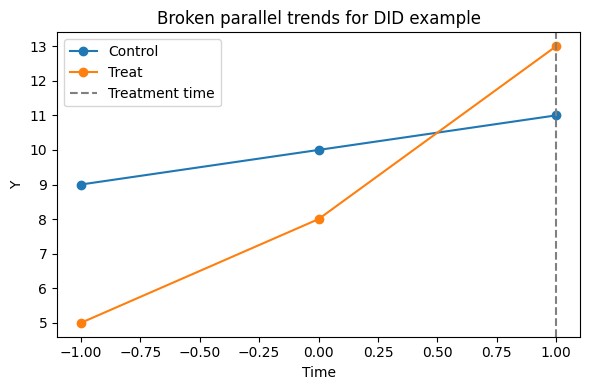

In [41]:
d_plot = d.sort_values(["group", "t"]).copy()

plt.figure(figsize=(6, 4))

# Plot each group over time
for g in d_plot["group"].unique():
    dg = d_plot[d_plot["group"] == g]
    plt.plot(dg["t"], dg["Y"], marker="o", label=g)

# Vertical line at the treatment time
plt.axvline(x=1, linestyle="--", color="gray", label="Treatment time")

plt.xlabel("Time")
plt.ylabel("Y")
plt.title("Broken parallel trends for DID example")
plt.legend()
plt.tight_layout()
plt.show()
